# Cellpose in Python

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../../notebooks/05_segmentation/deep_learning/cellpose_notebook.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/cellpose_notebook_colab.ipynb" target="_blank">
        <img class="button-icon" src="../../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "tifffile",
#     "cellpose"
# ]
# ///

## Overview

[Website](https://www.cellpose.org) | [GitHub](https://github.com/mouseland/cellpose) | [Paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1)

In this section, we’ll learn how to use **Cellpose**, a powerful deep learning tool for cell segmentation. Cellpose works on a wide variety of microscopy images—including both nuclei and full cells—and doesn’t require retraining for many common use cases.

We’ll start by running Cellpose on a single image and then move to batch processing and visualization. Later, we’ll explore how to customize parameters and interpret Cellpose outputs like masks and flow fields.

> 💡 Tip: If you're not using a GPU (or are on a Mac with Apple Silicon), we recommend running this notebook on **Google Colab** for faster performance.

## Import Libraries

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import tifffile
from cellpose import core, io, models, plot

## Setup

In [3]:
io.logger_setup()  # to get printing of progress

use_gpu = core.use_gpu()
print("GPU available:", use_gpu)

2026-06-01 17:39:32,965 [INFO] WRITING LOG OUTPUT TO /Users/fdrgsp/.cellpose/run.log
2026-06-01 17:39:32,966 [INFO] 
cellpose version: 	4.1.1 
platform:       	darwin 
python version: 	3.13.3 
torch version:  	2.12.0
2026-06-01 17:39:33,034 [INFO] ** TORCH MPS version installed and working. **
GPU available: True


## Run Cellpose on a Sample Image

In this section, we’ll apply Cellpose to a single image and visualize the segmentation result.

You’ll see how easy it is to segment cells using just a few lines of code. We’ll use the `model.eval()` function to make predictions, and then display:
- The original image
- The predicted segmentation mask
- The outlines of detected cells
- The flow fields that Cellpose uses to group pixels into objects

No model training required—just load, run, and view the results.

### Load the Image

In [4]:
image_path = "../../../_static/images/cellpose/cell_cellpose.tif"
image = tifffile.imread(image_path)

print(image.shape)

(2, 1040, 1392)


### Initialize the Model

To initialize Cellpose model we can use the [`models.CellposeModel()`](https://cellpose.readthedocs.io/en/latest/api.html#cellposemodel) class.

Among the parameters we can set if we want to use `gpu` (if available) as well which **model** to use. The current default is Cellpose-SAM as `cpsam` (another example is `cyto3`, the previous U-Net-based model).

If it is the first time you run this notebook, the model will be downloaded automatically. This may take a while.

In [5]:
model = models.CellposeModel(gpu=use_gpu, pretrained_model="cpsam")

2026-06-01 17:58:14,592 [INFO] ** TORCH MPS version installed and working. **
2026-06-01 17:58:14,593 [INFO] >>>> using GPU (MPS)
2026-06-01 17:58:15,173 [INFO] >>>> loading model /Users/fdrgsp/.cellpose/models/cpsam


### Run Cellpose

After initializing the model, we can run it on the image using the `model.eval()` method (see hidden cell below for parameters details).

### CellposeSam `model.eval()` Parameters

```python
model.eval(
    x,
    channel_axis=None,
    normalize=True,
    invert=False,
    diameter=None,
    flow_threshold=0.4,
    cellprob_threshold=0.0,
    min_size=15,
    max_size_fraction=0.4,
    niter=None,
    compute_masks=True,
    batch_size=8,
    resample=True,
    bsize=256,
    tile_overlap=0.1,
    augment=False,
    do_3D=False,
    z_axis=None,
    anisotropy=None,
    flow3D_smooth=0,
    stitch_threshold=0.0,
    progress=None,
)
```

**Input**

| Parameter | Default | Description |
|---|---|---|
| `x` | — | A single image or list of images (2D/3D/4D). For `cpsam`, up to 3 channels are used. |
| `channel_axis` | `None` | Which axis of `x` is the channel axis. If `None`, Cellpose auto-detects it. |

**Preprocessing**

| Parameter | Default | Description |
|---|---|---|
| `normalize` | `True` | Normalize intensities to 0–1 using 1st/99th percentile. Pass `False` to skip, or a dict for fine-grained control (see below). |
| `invert` | `False` | Invert pixel intensities before running the network. Useful for brightfield images where cells are dark on a bright background. |
| `diameter` | `None` | Expected cell diameter in pixels. Used to rescale the image so cells appear ~30 px wide to the model. If `None`, no rescaling is applied. |

When passing `normalize` as a dict, all keys are optional and can be combined:

```python
# Tile-based normalization: useful when illumination is uneven across the image.
# The image is split into blocks of ~100 px and each block is normalized independently.
normalize = {"tile_norm_blocksize": 100}

# Fixed intensity range: skip percentile computation and clamp to known values.
normalize = {"lowhigh": [200, 4000]}

# Custom percentiles instead of the default 1st/99th.
normalize = {"percentile": [5, 95]}

# Sharpen before segmenting (value ≈ 1/4 to 1/8 of cell diameter in px).
normalize = {"sharpen": 5}

# Keys can be combined — e.g. tile normalization + custom percentiles:
normalize = {"tile_norm_blocksize": 100, "percentile": [2, 98]}
```

**Segmentation quality**

| Parameter | Default | Description |
|---|---|---|
| `flow_threshold` | `0.4` | Maximum allowed flow error for a mask to be kept. **Increase** to recover more masks (or set to `0.0` to keep all); **decrease** to discard ill-shaped masks. Not used in 3D. |
| `cellprob_threshold` | `0.0` | Minimum cell probability for a pixel to be included in a mask. **Decrease** to find more/larger masks; **increase** to suppress dim or spurious detections. |
| `min_size` | `15` | Minimum mask area in pixels. Smaller objects are discarded. |
| `max_size_fraction` | `0.4` | Masks larger than this fraction of the total image area are removed (catches runaway segmentations). |
| `niter` | `None` | Number of iterations for the flow integration step. If `None`, set automatically proportional to `diameter`. |
| `compute_masks` | `True` | If `False`, skips flow integration and returns empty masks (useful to get flows/styles only). |

**Performance**

| Parameter | Default | Description |
|---|---|---|
| `batch_size` | `8` | Number of 256×256 tiles processed per GPU forward pass. Increase for faster throughput (uses more GPU memory); decrease if you hit out-of-memory errors. |
| `resample` | `True` | Run flow dynamics at the original image resolution. Slower but produces more accurate boundaries. |
| `bsize` | `256` | Tile size used by the network. Keep at 256 (matches training). |
| `tile_overlap` | `0.1` | Fractional overlap between adjacent tiles. Helps avoid boundary artifacts. |
| `augment` | `False` | Tile the image with overlapping tiles and flip augmentation. Slightly more accurate but slower. |

**3D segmentation**

| Parameter | Default | Description |
|---|---|---|
| `do_3D` | `False` | Set to `True` to run full 3D segmentation on a Z-stack. |
| `z_axis` | `None` | Which axis is the Z axis (for 3D images). If `None`, auto-detected. |
| `anisotropy` | `None` | Z-to-XY voxel size ratio (e.g. `2.0` if Z is sampled at half the XY density). Used to rescale the Z axis before 3D segmentation. |
| `flow3D_smooth` | `0` | Smooth 3D flows with a Gaussian filter of this stddev. Helps reduce Z-fragmentation and ring artifacts. Can be a list `[z, y, x]` for axis-independent smoothing. |
| `stitch_threshold` | `0.0` | If `> 0` and `do_3D=False`, stitch 2D masks across Z slices into a 3D volume. |

**Returns**

| Output | Description |
|---|---|
| `masks` | 2D label array (or list of them). `0` = background; `1, 2, …` = individual cell IDs. |
| `flows` | List of flow outputs per image: `flows[0]` = RGB flow visualization; `flows[1]` = XY flow vectors; `flows[2]` = cell probability map. |
| `styles` | Style vectors (legacy, all zeros for `cpsam`). |

In [6]:
masks, flows, styles = model.eval(image)

/Users/fdrgsp/Documents/git/bobiac-book/.venv/lib/python3.13/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


### Display the Results

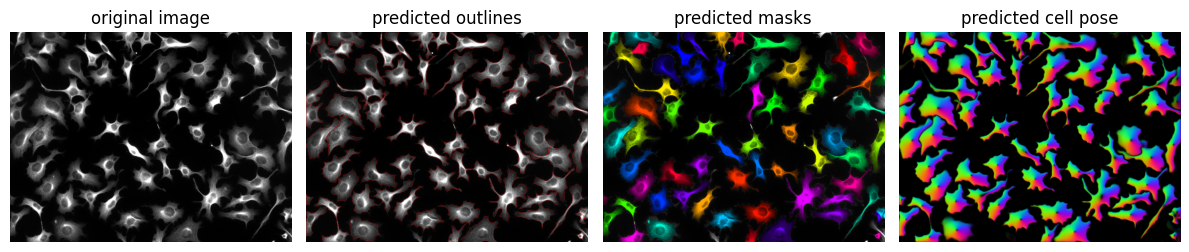

In [11]:
fig = plt.figure(figsize=(12, 5))
plot.show_segmentation(fig, image[1], masks, flows[0])
plt.tight_layout()
# Optional if you want to also save the figure
# plt.savefig(f"path/to/output/{Path(image_path).stem}_cp_output.png")
plt.show()

<div align="left"> <img src="https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/cellpose/cellpose_out.png" alt="Ilastik Logo" width="1000"></div>

## Run Cellpose on a Folder of Images

Now that we’ve seen how to run Cellpose on a single image, let’s scale up and apply it to a **folder of images**. This is useful when you have an entire experiment or dataset that you want to segment automatically.

Cellpose provides a convenient built-in function for this: `model.eval()` can be used with a folder path, and it will process all compatible image files in that folder.

We’ll walk through how to:
- Point Cellpose to your image directory
- Choose the segmentation type (e.g., "nuclei" or "cyto")
- Set output options like saving masks and outlines
- Visualize a few results to make sure everything worked

> 💡 Tip: Make sure your images are in `.tif`, `.png`, or `.jpg` format.

Let’s get started with folder-based segmentation!


In [ ]:
folder_path = Path("data/05_segmentation_cellpose")

# Read all images and their paths
image_files = sorted(folder_path.glob("*.tif"))
images = [tifffile.imread(f) for f in image_files]

# Cellpose parameters
batch_size = 8  # number of 256x256 tiles processed simultaneously on the GPU
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

# Run Cellpose on all images at once
all_masks, all_flows, all_styles = model.eval(
    images,
    batch_size=batch_size,
    flow_threshold=flow_threshold,
    cellprob_threshold=cellprob_threshold,
    normalize={"tile_norm_blocksize": tile_norm_blocksize},
)

# Save the segmentation results
for image_path, masks in zip(image_files, all_masks):
    output_path = folder_path / f"{image_path.stem}_labeled_mask.tif"
    tifffile.imwrite(output_path, masks.astype("uint16"))